<a href="https://colab.research.google.com/github/tensorbytes0202/Deep-learning/blob/main/comparision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import zipfile

zip_path = "/content/drive/MyDrive/Untitled folder/archive (4).zip"  # apna filename check kar lena
extract_path = "/content/tiny-imagenet"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Done ✅")

Extraction Done ✅


In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [26]:
transform = transforms.Compose([
    transforms.Resize((64,64)), # Changed resize to 64x64 to match CNN's expected input features
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_data = datasets.ImageFolder(
    "/content/tiny-imagenet/tiny-imagenet-200/val/structured_val", # Point to the new structured validation directory
    transform=transform
)

# 🔥 FAST subset (2000 images)
val_subset = Subset(val_data, list(range(2000)))

val_loader = DataLoader(val_subset, batch_size=32)

In [16]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Linear(8192,256), # Corrected input size for the first linear layer to 8192
            nn.ReLU(),
            nn.Linear(256,200)
        )

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0),-1)
        return self.fc(x)

In [22]:
# CNN
cnn = CNN()
cnn.load_state_dict(torch.load("model (1).pth", map_location=torch.device('cpu')))
cnn.to(device)
cnn.eval()

# ResNet
resnet = models.resnet18(pretrained=False)
resnet.fc = nn.Linear(resnet.fc.in_features, 200)

resnet.load_state_dict(torch.load("resnet_model (1).pth", map_location=torch.device('cpu')))
resnet.to(device)
resnet.eval()

# MobileNet
mobilenet = models.mobilenet_v2(pretrained=False)

mobilenet.classifier[1] = nn.Linear(
    mobilenet.classifier[1].in_features, 200
)

mobilenet.load_state_dict(torch.load("mobilenet_model.pth", map_location=torch.device('cpu')))
mobilenet.to(device)
mobilenet.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [19]:
def evaluate(model):
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, pred = torch.max(outputs,1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

    return 100 * correct / total

In [27]:
cnn_acc = evaluate(cnn)
resnet_acc = evaluate(resnet)
mobilenet_acc = evaluate(mobilenet)

print("\n===== FINAL RESULTS ====")
print(f"CNN        → {cnn_acc:.2f}%")
print(f"ResNet     → {resnet_acc:.2f}%")
print(f"MobileNet  → {mobilenet_acc:.2f}%")


===== FINAL RESULTS ====
CNN        → 2.25%
ResNet     → 5.90%
MobileNet  → 3.60%


In [24]:
for images, _ in val_loader:
    print(f"Shape of images in a batch: {images.shape}")
    break

Shape of images in a batch: torch.Size([32, 3, 64, 64])


In [25]:
import os
import shutil

# Path to the base validation directory
val_dir_base = "/content/tiny-imagenet/tiny-imagenet-200/val"
val_annotations_path = os.path.join(val_dir_base, "val_annotations.txt")
val_images_dir_original = os.path.join(val_dir_base, "images")

# Create a new directory for the structured validation set
structured_val_dir = os.path.join(val_dir_base, "structured_val")
os.makedirs(structured_val_dir, exist_ok=True)

# Read val_annotations.txt to get image-to-class mappings
image_to_class_id = {}
with open(val_annotations_path, 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        image_filename = parts[0]
        class_id = parts[1] # e.g., n03444034
        image_to_class_id[image_filename] = class_id

# Restructure the validation images
print(f"Restructuring Tiny-ImageNet validation set in {val_dir_base}...")
for image_filename, class_id in image_to_class_id.items():
    # Create class subdirectory if it doesn't exist
    class_path = os.path.join(structured_val_dir, class_id)
    os.makedirs(class_path, exist_ok=True)

    src_path = os.path.join(val_images_dir_original, image_filename)
    dst_path = os.path.join(class_path, image_filename)

    # Move the image
    if os.path.exists(src_path) and not os.path.exists(dst_path): # Check if source exists and destination doesn't
        shutil.move(src_path, dst_path)
    elif os.path.exists(dst_path):
        pass # Image already moved, or was copied in a previous run
    else:
        print(f"Warning: Source image {src_path} not found.")

print("Validation set restructuring complete.")

Restructuring Tiny-ImageNet validation set in /content/tiny-imagenet/tiny-imagenet-200/val...
Validation set restructuring complete.


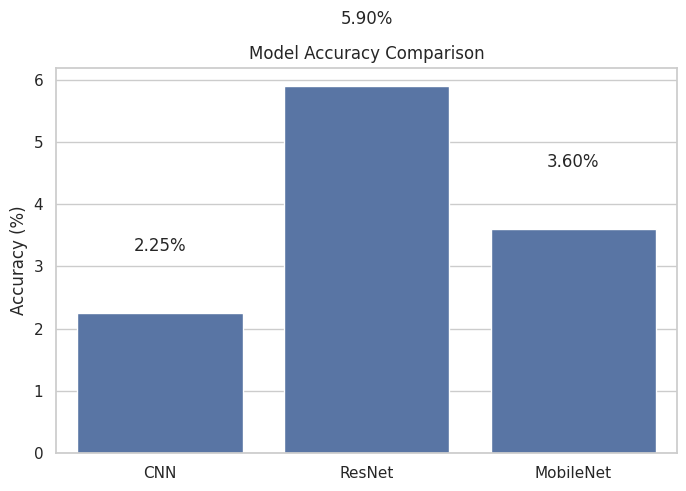

In [28]:
sns.set(style="whitegrid")

models = ["CNN", "ResNet", "MobileNet"]
accuracies = [cnn_acc, resnet_acc, mobilenet_acc]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")

for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')

plt.show()